# Figure out full calibration-testing-fe comparison pipeline
- and populate helpers.py

In [1]:
import numpy as np
from pathlib import Path
import pyvista as pv
import matplotlib.pyplot as plt

from phd_helpers.experiments import parse_tekscan

from helpers import (
    compute_power_law_coeffs, compute_img_metrics, compute_fe_grid_data, build_fe_data, fe_mets_from_mesh, compute_CA_overlap
)

# Paths

In [2]:
exp_path = Path('../../../../Experimental/LabData/contactTesting/20260904')

In [3]:
cal_1_paths = list(exp_path.glob('calibration/cal_1*.asm'))
redos = [500, 700, 900]
redo_names = [f'cal_1_{x}N.asm' for x in redos]
cal_1_paths = [x for x in cal_1_paths if x.name not in redo_names]
def F_from_path(path):
    return int(path.name.split('N')[0].split('_')[-1])
cal_1_Fs = [F_from_path(x) for x in cal_1_paths]
cal_1_Fs

[900, 10, 300, 140, 60, 20, 100, 800, 400, 500, 600, 180, 220, 700, 260]

In [4]:
test_14548_1_paths = list(exp_path.glob('testing/14548R/neu_1*.asm'))
test_14548_1_Fs = [F_from_path(x) for x in test_14548_1_paths]
test_14548_1_Fs

[60, 40, 20, 125, 10, 150, 100, 80]

In [ ]:
#fea_path = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study3_50017L_fle')
#inp_file = list(fea_path.glob('**/*.inp'))[0]
fea_path = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy')
inp_file = list(fea_path.glob('study3_35T*/**/*.inp'))[0]
inp_file

PosixPath('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study3_35T4d5_Fsteps/inpFiles/14548R/inp/35T-neutral-00/35T-neutral-00.inp')

# Identify hold frames
- Has to be done by identifying end of hold and hold time
- Below method finds idx immediately before or after the drop (so within 0.0625 s)
    - checked on all calibration frames

In [ ]:
def compute_hold_end_idx(frames):
    y = frames.sum(axis=(1, 2))
    return  np.argmin(np.gradient(np.gradient(y))) - 1
def compute_hold_start_idx(end_idx, hold_time, spf):
    n_frames = round(hold_time / spf)
    return max(0, end_idx - n_frames)

def get_hold_frames(frames, hold_time, spf, start_idx=None, end_idx=None):
    """Requires that tekscan sensor recording started before and ended after the hold period (with rapid-ish unloading)"""
    if end_idx is None:
        end_idx = compute_hold_end_idx(frames)
    if start_idx is None:
        start_idx = compute_hold_start_idx(end_idx, hold_time, spf)
    return frames[start_idx: end_idx+1]

def avg_frames(frames, raw_mask=0):
    """raw mask sets values <= to raw mask to zero"""
    frame = np.mean(frames, axis=0)
    frame[frame <= raw_mask] = 0
    return frame

def get_avg_hold_frame(hold_frames, start_time, avg_window_time, spf, raw_mask=0):
    """
    hold_frames: tekscan frames during force hold
    start_time: seconds into hold_frames to start the hold window
    avg_window_time: time window over which to average the frames
    """
    n_frames = round(avg_window_time / spf)
    start_frame = round(start_time / spf)
    end_frame = start_frame + n_frames
    frames = hold_frames[start_frame:end_frame+1]
    return avg_frames(frames, raw_mask)

### Calibration frames
- looks good
- except for 60 N which has spf of 0.1
    - must have been more like 0.101

SPF:  0.0625


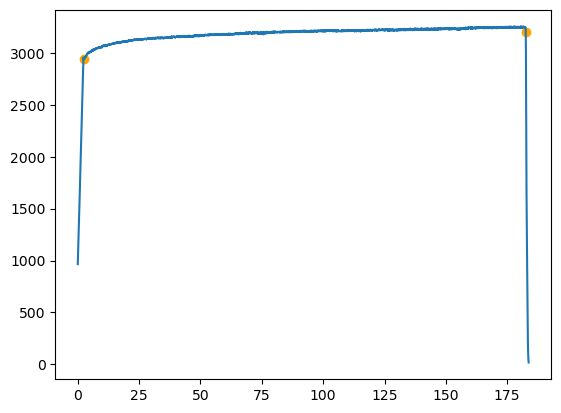

In [88]:
sensor_id = 3
path = cal_1_paths[3]
hold_time = 180 # s

frames, spf = parse_tekscan(path, sensor_id, return_spf=True)
#spf = 0.101
print('SPF: ', spf)
y = frames.sum(axis=(1, 2))
x = np.arange(y.shape[0])*spf

end_idx = compute_hold_end_idx(frames)
start_idx = compute_hold_start_idx(end_idx, hold_time, spf)

plt.plot(x, y)
plt.scatter(x[start_idx], y[start_idx], color='orange')
plt.scatter(x[end_idx], y[end_idx], color='orange')
plt.show()

In [89]:
y[end_idx]

np.float64(3201.0)

In [90]:
# finds the one before or after drop
y[end_idx-10:]

array([3247., 3246., 3251., 3249., 3247., 3247., 3246., 3249., 3248.,
       3243., 3201., 3010., 2619., 2218., 1928., 1653., 1443., 1257.,
       1107.,  950.,  783.,  624.,  475.,  332.,  205.,  131.,   86.,
         41.,   27.,   17.])

In [ ]:
start_time = 179
avg_window_time = 1
frames, spf = parse_tekscan(path, sensor_id, return_spf=True)
hold_frames = get_hold_frames(frames, hold_time, spf)
get_avg_hold_frame(hold_frames, start_time, avg_window_time, spf).sum()
# looks good

np.float64(11833.470588235294)

### Testing
- looks good

10 N
SPF:  0.0625
214.88235294117646


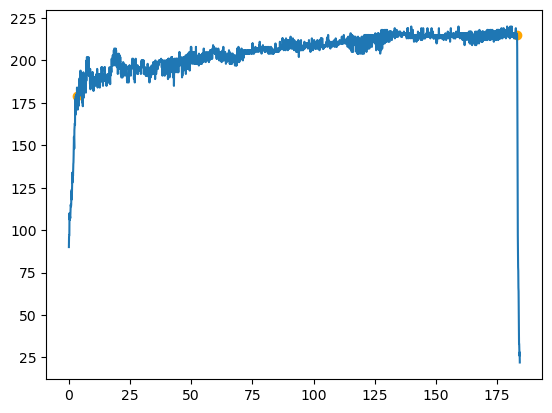

In [28]:
i = 4
print(test_14548_1_Fs[i], 'N')

sensor_id = 3
path = test_14548_1_paths[i]
hold_time = 180 # s
start_time = 179
avg_window_time = 1

frames, spf = parse_tekscan(path, sensor_id, return_spf=True)
print('SPF: ', spf)
y = frames.sum(axis=(1, 2))
x = np.arange(y.shape[0])*spf

end_idx = compute_hold_end_idx(frames)
start_idx = compute_hold_start_idx(end_idx, hold_time, spf)

frames, spf = parse_tekscan(path, sensor_id, return_spf=True)
hold_frames = get_hold_frames(frames, hold_time, spf)
print(get_avg_hold_frame(hold_frames, start_time, avg_window_time, spf).sum())

plt.plot(x, y)
plt.scatter(x[start_idx], y[start_idx], color='orange')
plt.scatter(x[end_idx], y[end_idx], color='orange')
plt.show()

In [29]:
y[end_idx]

np.float64(215.0)

In [30]:
# finds the one before or after drop
y[end_idx-10:]

array([215., 216., 219., 213., 214., 215., 215., 216., 214., 215., 215.,
       207., 175., 132., 106.,  97.,  87.,  78.,  76.,  66.,  64.,  53.,
        42.,  33.,  33.,  28.,  26.,  28.,  22.])

# Calibration
- print and store coeffs
    - easy to collect coeffs together to try different calibration fits
- plot comparison of calibration frames with true force
    - print and store avg and max error
- easy to compare changes in inputs
    - plot resulting calibration curves

In [ ]:
def avg_frames_from_paths(paths, Fs, sensor_id, hold_time, start_time, avg_window, custom_masks=[], raw_mask=0):
    avg_frames = {}
    for path in paths:
        F = F_from_path(path)

        if F not in Fs:
            continue

        frames, spf = parse_tekscan(path, sensor_id, return_spf=True)
        #•••••••••••• custom mask for noisy cells ••••••••••••#
        for custom_mask in custom_masks:
            mask_value, j, k = custom_mask
            mask = frames[:, j, k] <= mask_value
            frames[mask, j, k] = 0
        #•••••••••••• custom mask for noisy cells ••••••••••••#
        hold_frames = get_hold_frames(frames, hold_time, spf)
        frame = get_avg_hold_frame(hold_frames, start_time, avg_window, spf, raw_mask)

        avg_frames[F] = frame
    return avg_frames

def apply_ab_fit(a, b, frames):
    "returns frames with fit a*frame**b applied and predicted total force per frame and % error per frame"
    return {f: a * frame**b for f, frame in frames.items()}

def compute_error(pred_Fs):
    error = [100*np.abs(p - f)/f for f, p in pred_Fs.items()]
    error_mean = np.mean(error)
    error_max = np.max(error)
    print(f'Mean error: {error_mean:.2f} %\n Max error: {error_max:.2f} %')

In [ ]:
sensor_id = 3
raw_mask = 0
custom_masks = [[4, -1, 0]] # [[raw_mask_value, j_idx, k_idx], ...]
hold_time = 180
avg_window = 5

cal_Fs = sorted(cal_1_Fs)
cal_start_time = 55

cal_frames = avg_frames_from_paths(cal_1_paths, cal_Fs, sensor_id, hold_time, cal_start_time, avg_window, custom_masks, raw_mask)

a, b = compute_power_law_coeffs(cal_frames)
cal_frames_mpa = apply_ab_fit(a, b, cal_frames)
cal_mets = {f: compute_img_metrics(frame) for f, frame in cal_frames_mpa.items()}
cal_pred_Fs = {f: cal_mets[f]['pred_F'] for f in cal_mets}
compute_error(cal_pred_Fs)

Mean error: 7.69 %
 Max error: 44.12 %


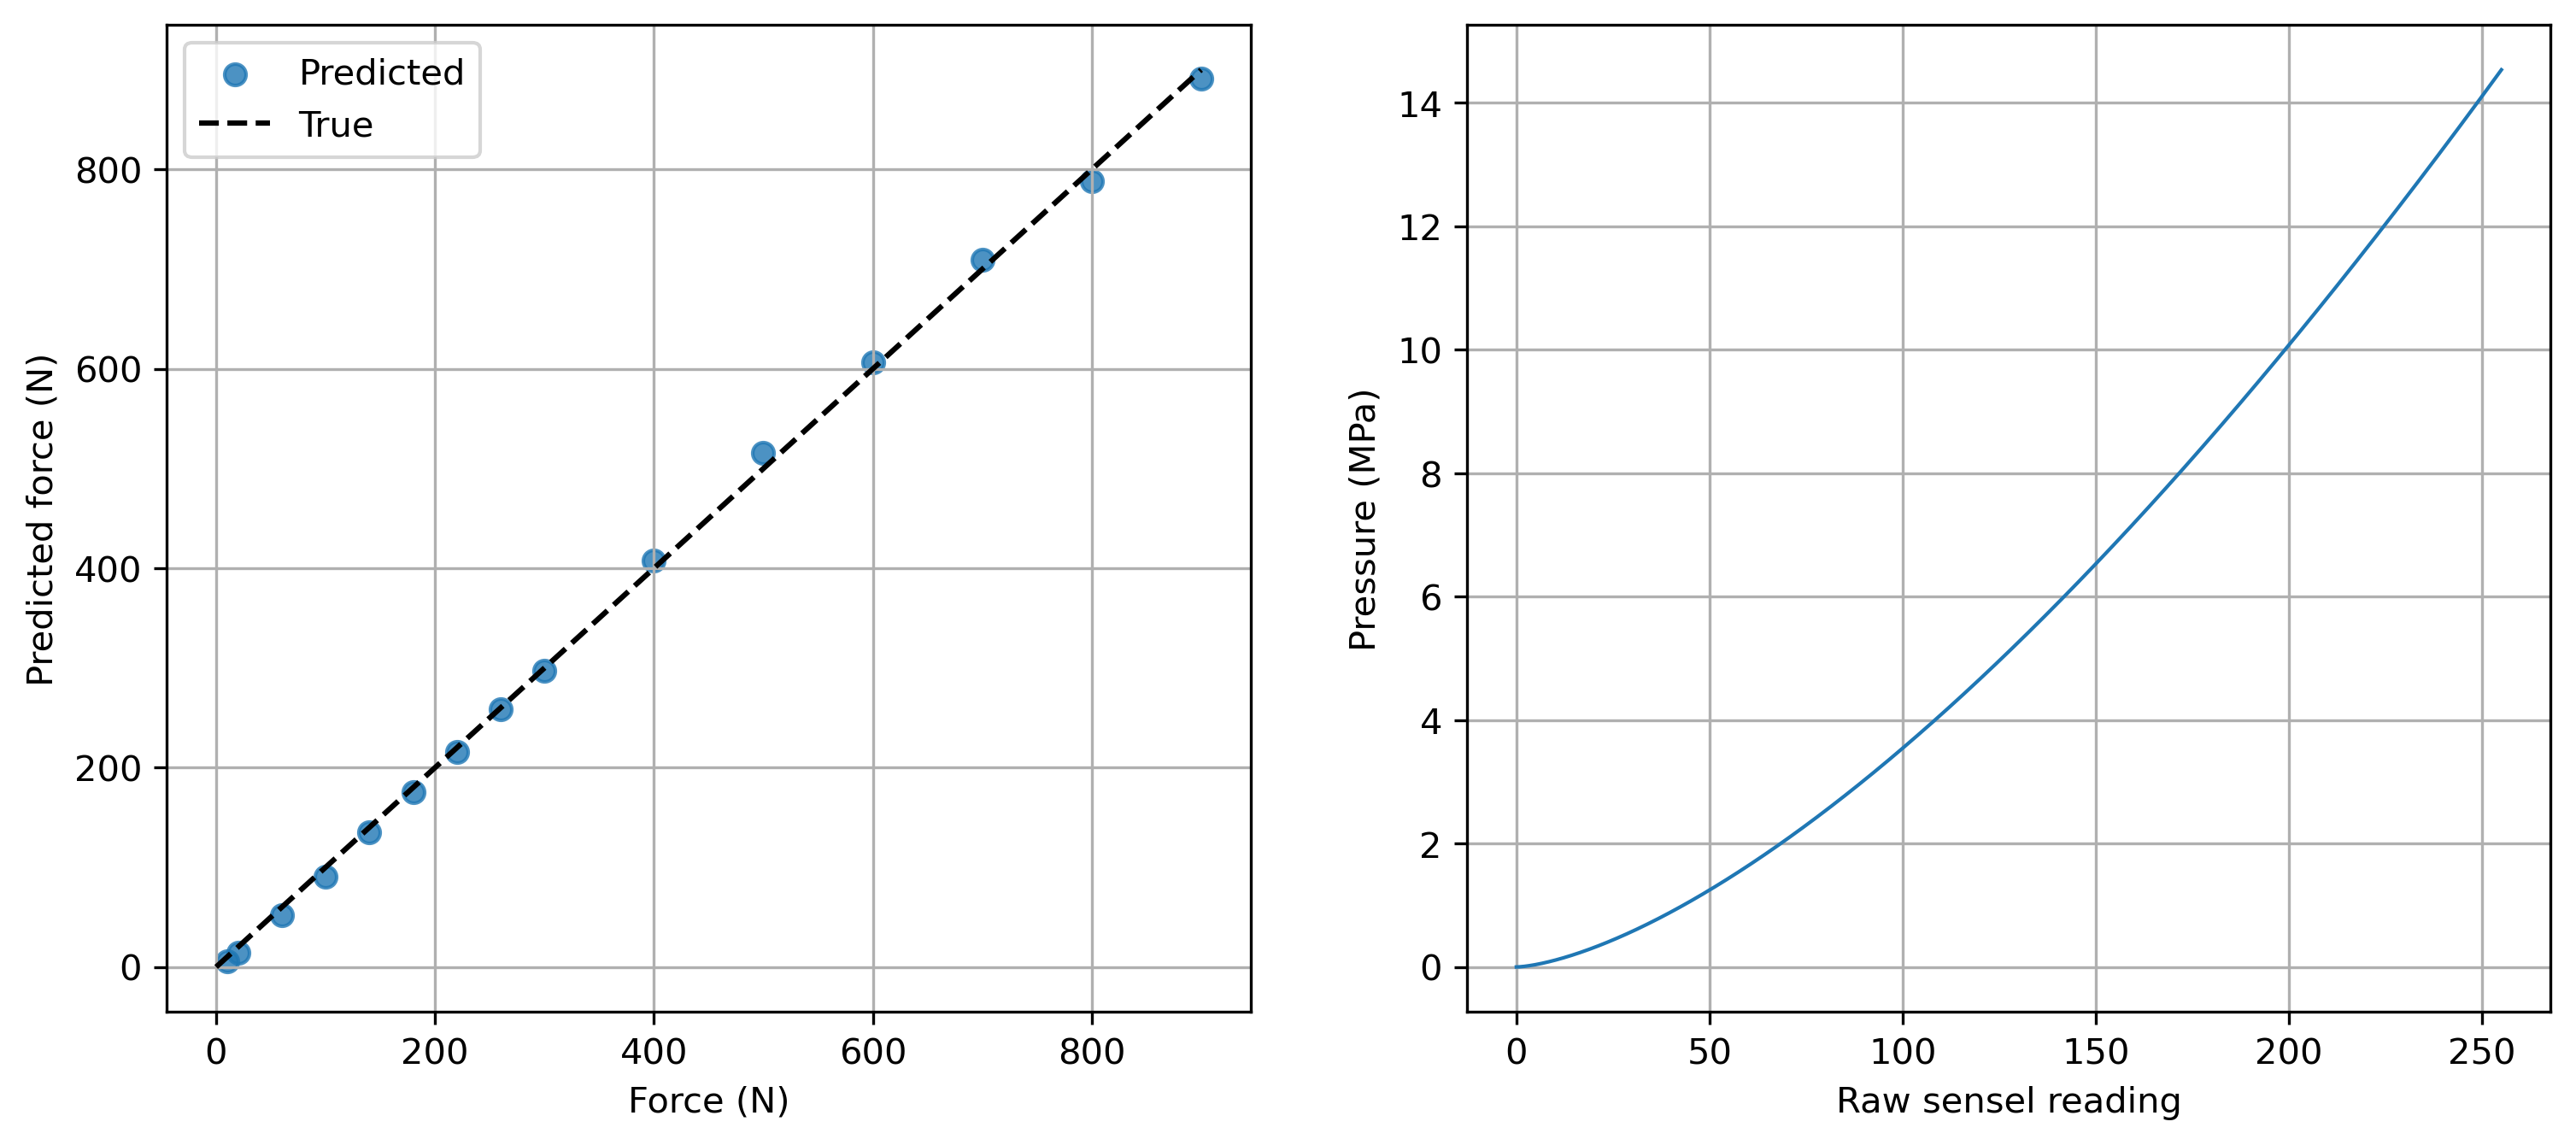

In [9]:
ncols, nrows = 2, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), dpi=300)

# calibration frame comparison
fs, ps = [], []
for f, p in cal_pred_Fs.items():
    fs.append(f)
    ps.append(p)
ax[0].scatter(fs, ps, alpha=0.8, label='Predicted')
ax[0].plot([0, max(fs)], [0, max(fs)], linestyle='--', color='black', label='True')

# raw sensel fit
xs = np.linspace(0, 255, 1000)
ys = (a*xs**b)
ax[1].plot(xs, ys, linewidth=1)


ax[0].set_xlabel('Force (N)')
ax[0].set_ylabel('Predicted force (N)')
ax[0].grid()
ax[0].legend()

ax[1].set_xlabel('Raw sensel reading')
ax[1].set_ylabel('Pressure (MPa)')
ax[1].grid()
plt.show()

# Experimental results
- compare with true force
    - print and store avg and max error
- output dict of tek_mets for each force

In [ ]:
test_Fs = sorted(test_14548_1_Fs)
test_start_time = 55

test_frames = avg_frames_from_paths(test_14548_1_paths, test_Fs, sensor_id, hold_time, test_start_time, avg_window, custom_masks, raw_mask)
test_frames_mpa = apply_ab_fit(a, b, test_frames)
test_mets = {f: compute_img_metrics(frame) for f, frame in test_frames_mpa.items()}
test_pred_Fs = {f: test_mets[f]['pred_F'] for f in test_mets}
compute_error(test_pred_Fs)

Mean error: 13.16 %
 Max error: 46.81 %


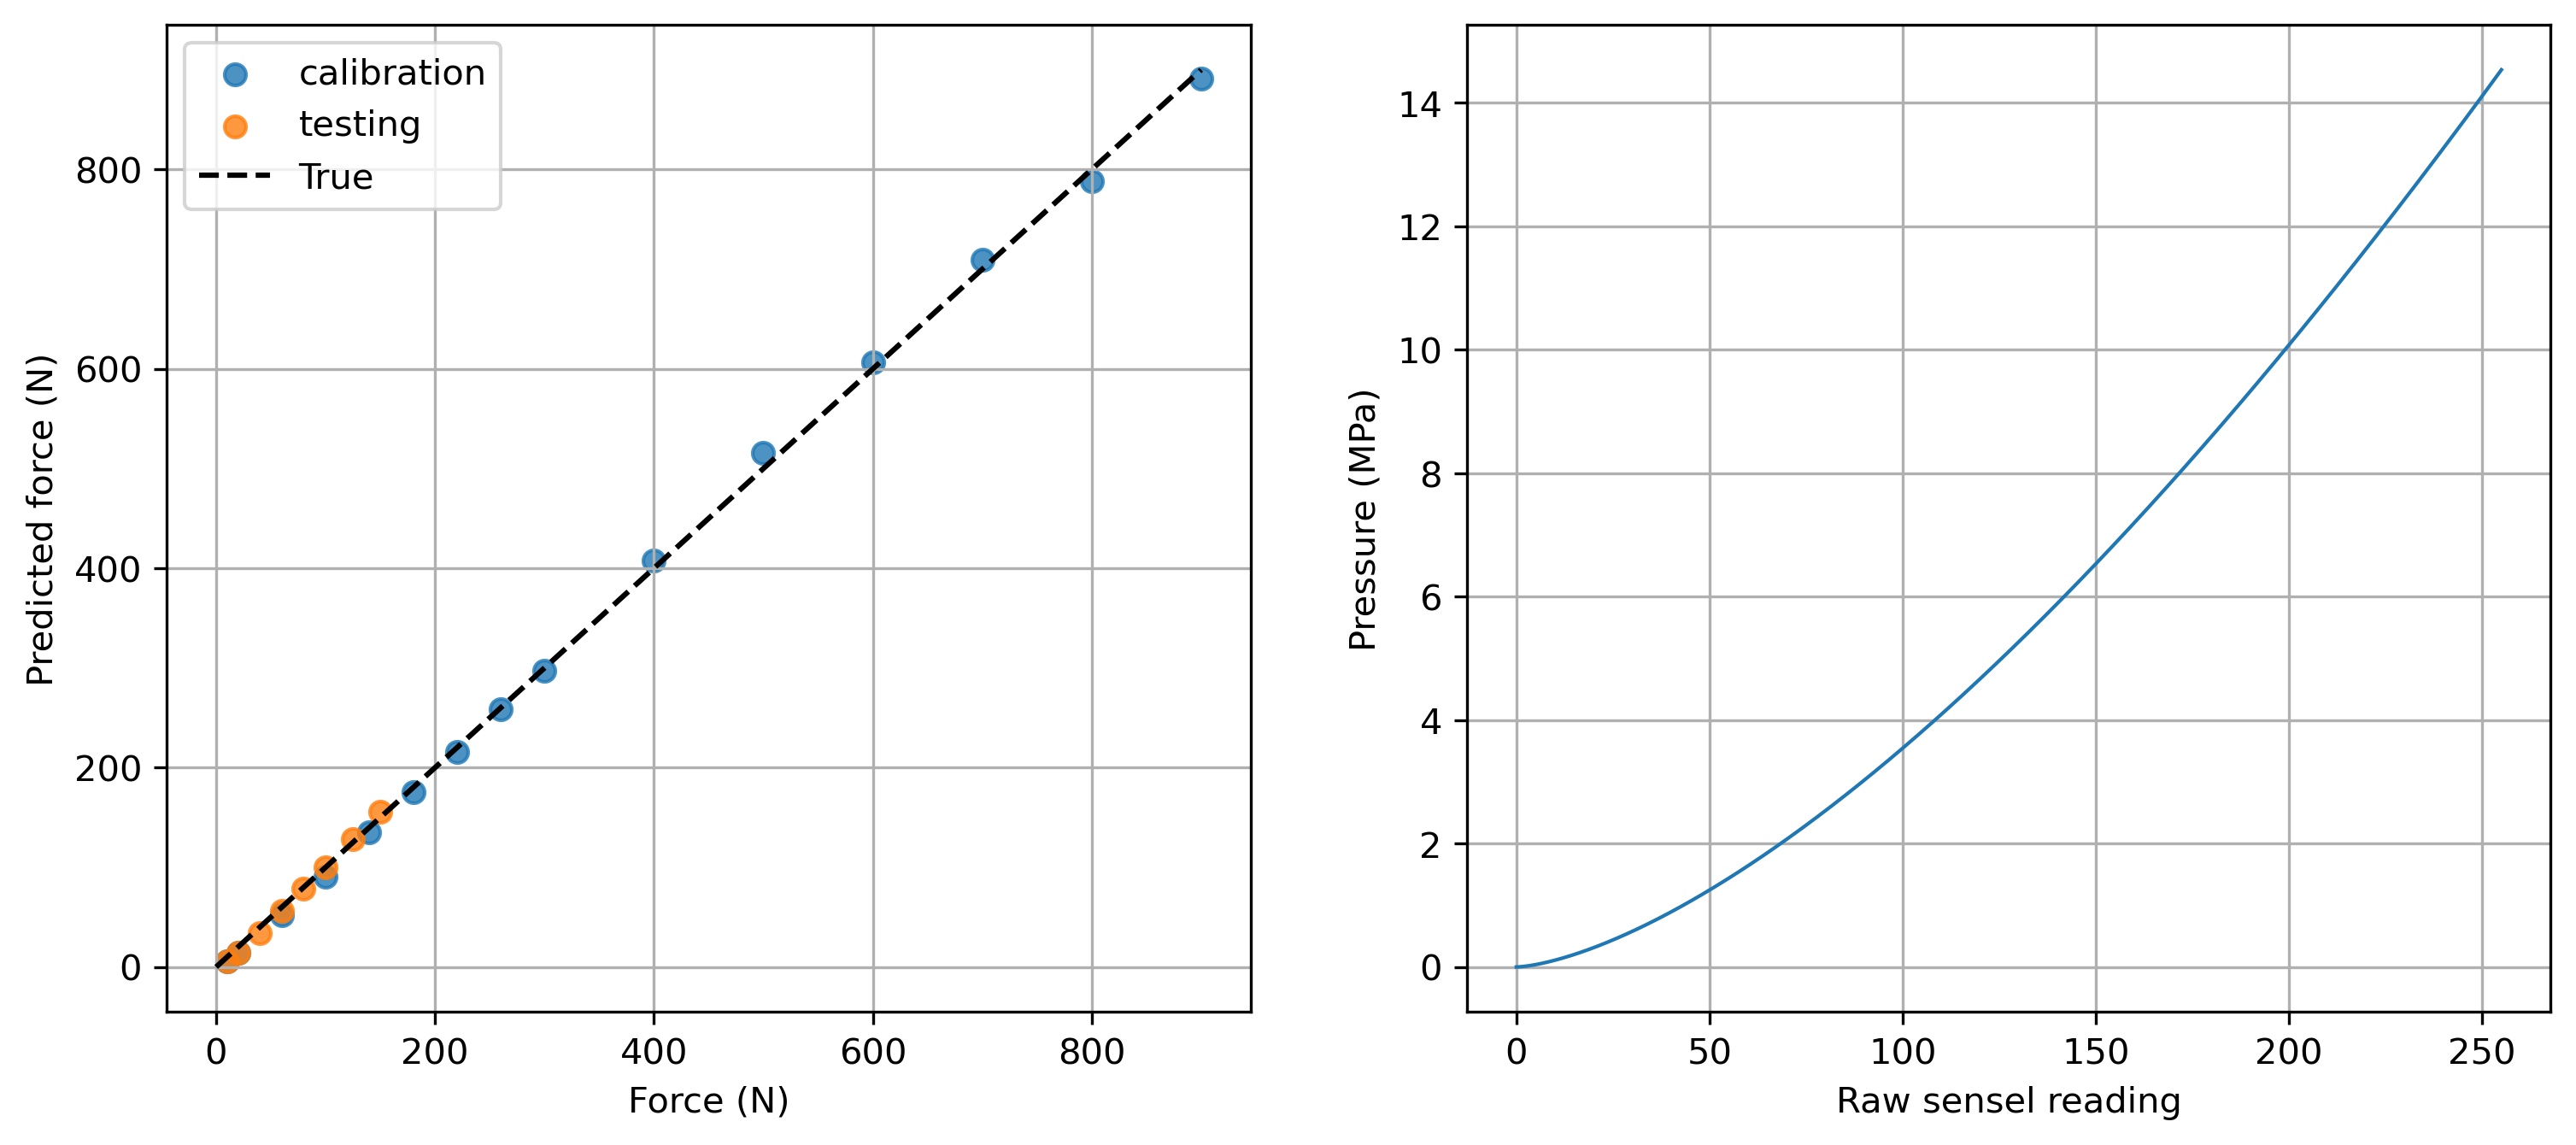

In [11]:
ncols, nrows = 2, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), dpi=300)

labels = ['calibration', 'testing']
preds = [cal_pred_Fs, test_pred_Fs]
# calibration frame comparison
for pred, label in zip(preds, labels):
    fs, ps = [], []
    for f, p in pred.items():
        fs.append(f)
        ps.append(p)
    ax[0].scatter(fs, ps, alpha=0.8, label=label)
ax[0].plot([0, max(cal_pred_Fs.keys())], [0, max(cal_pred_Fs.keys())], linestyle='--', color='black', label='True')

# raw sensel fit
xs = np.linspace(0, 255, 1000)
ys = (a*xs**b)
ax[1].plot(xs, ys, linewidth=1)


ax[0].set_xlabel('Force (N)')
ax[0].set_ylabel('Predicted force (N)')
ax[0].grid()
ax[0].legend()

ax[1].set_xlabel('Raw sensel reading')
ax[1].set_ylabel('Pressure (MPa)')
ax[1].grid()
plt.show()

# FE results
- output dict of down_mets and raw_mets for each force
- check which axis is aligned with instron transverse plane
- run simulations for both tested offset by 0.5 and 1mm in that direction

In [12]:
fe_data = build_fe_data(inp_file)

guide_wall_z = 10
sensor_offset = -2
bone = 'tpm'
common_Fs = set(fe_data) & set(test_frames)
fe_grid_data = compute_fe_grid_data(common_Fs, fe_data, test_frames_mpa, bone, guide_wall_z, sensor_offset)
fe_grid_mets = {f: compute_img_metrics(frame) for f, frame in fe_grid_data.items()}
fe_mets = {f: fe_mets_from_mesh(fe_data[f][bone]) for f in fe_data}

# Comparison
- compare how final results are affected by:
    - calibration inputs
    - testing inputs
- fe results don't change unless looking at misalignment

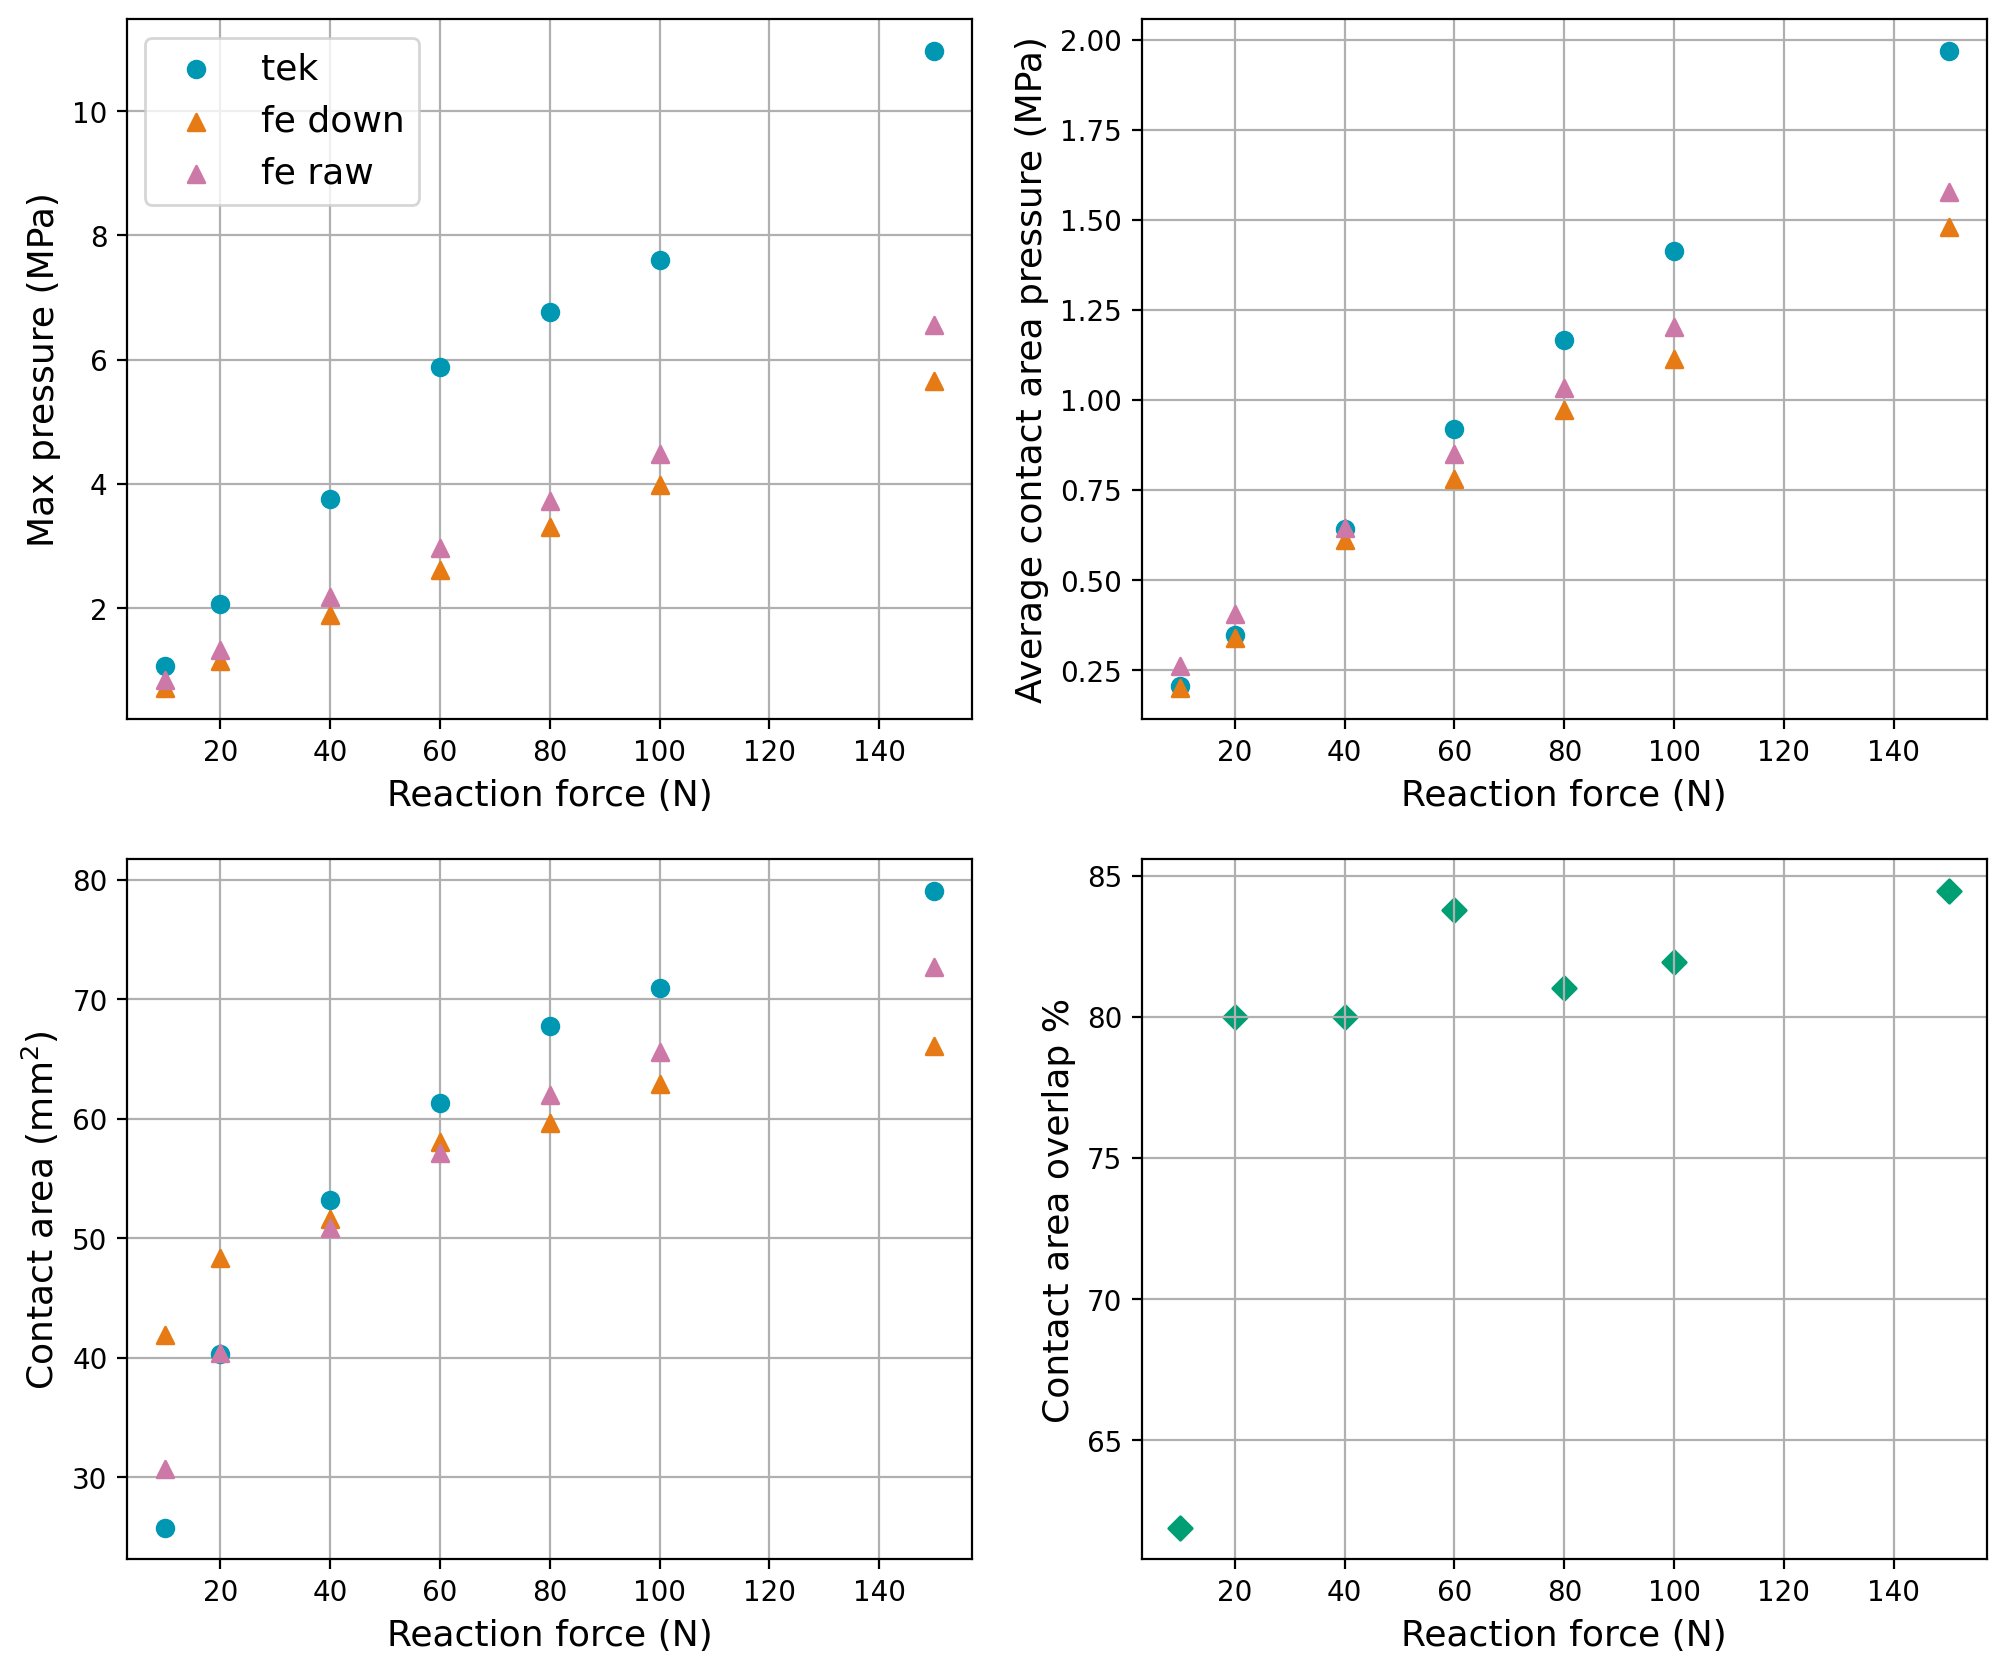

In [13]:
nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)
ax = ax.flatten()


fs = 13
colors = {
    "tek": "#0097b2",
         #"#009e73"
    "fe down": "#e67a14",
    'fe raw': "#cc79a7"
         #"#cc79a7"
         #"#bfb200"
    }
markers = {
    "tek": "o", 
    "fe down": "^",
    'fe raw': "^"
}

mets = ['P_max', 'P_avg', 'CA']
mets_datas = [test_mets, fe_grid_mets, fe_mets]
mets_labels = ['tek', 'fe down', 'fe raw']

x = list(common_Fs)
for mets_data, mets_label in zip(mets_datas, mets_labels):
    for i, met in enumerate(mets):
        y = [mets_data[f][met] for f in x]
        label = mets_label if mets_label == 'tek' else None
        ax[i].scatter(x, y, c=colors[mets_label], marker=markers[mets_label], label=mets_label, zorder=2)
        #ax[2].errorbar(F, tek_mets['CA'], yerr=[[tek_mets['CA_e_low']], [tek_mets['CA_e_high']]] , c=colors['tek'], marker=markers['tek'], capsize=5, elinewidth=0.8)

for f in x:
    ax[3].scatter(f, compute_CA_overlap(fe_grid_data[f], test_frames_mpa[f]), c="#009e73", marker="D")



ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Average contact area pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
ax[3].set_ylabel('Contact area overlap %', fontsize=fs)
for ax_i in ax:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[0].legend(fontsize=fs)
#ax[3].legend(fontsize=fs)
plt.show()

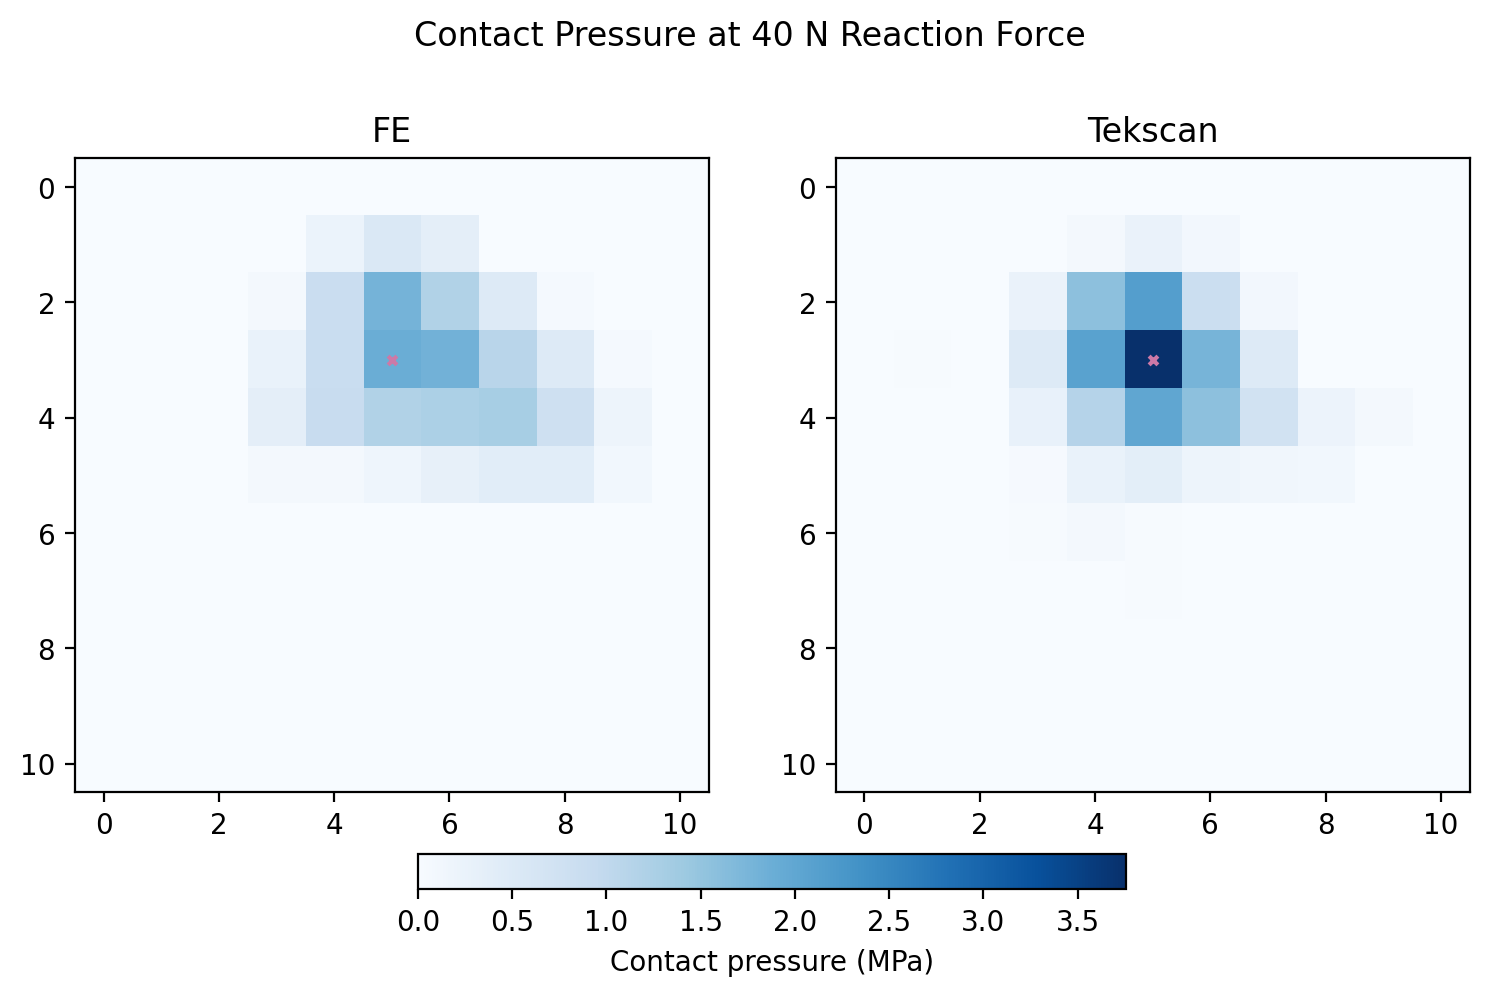

In [24]:
F = 40

nrows, ncols = 1, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 5*nrows), dpi=200)

P_fea, P_tek = fe_grid_data[F][::-1], test_frames_mpa[F][::-1]

press_min = np.min( [np.min(P_fea), np.min(P_tek)] )
press_max = np.max( [np.max(P_fea), np.max(P_tek)] )
clims = (press_min, press_max)

# imshows
im = ax[0].imshow(P_fea, vmin=clims[0], vmax=clims[1], cmap="Blues")
ax[1].imshow(P_tek, vmin=clims[0], vmax=clims[1], cmap='Blues')

# peak pressure loc
y, x = compute_img_metrics(P_fea)['loc_Pmax']
ax[0].scatter(x, y, color="#cc79a7", s=10, marker='x')
y, x = compute_img_metrics(P_tek)['loc_Pmax']
ax[1].scatter(x, y, color="#cc79a7", s=10, marker='x')

ax[0].set_title('FE')
ax[1].set_title('Tekscan')
fig.suptitle(f'Contact Pressure at {F} N Reaction Force')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.08, orientation='horizontal')
cbar.set_label('Contact pressure (MPa)')

plt.show()